In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import random 
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score

sys.path.append('../') 
from src.preprocessing import load_data, clean_data, feature_engineer, split_data, preprocess_pipeline
from src.modeling import train_model, evaluate_model, save_model
from src.modeling import run_experiments

random.seed(42)
np.random.seed(42)

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

data_path = '../data/raw/horse_racing_data.csv'

raw_df_info = load_data(data_path)
logging.info(f"Исходный датасет: {raw_df_info.shape[0]} строк, {raw_df_info.shape[1]} столбцов.")
del raw_df_info 


2026-04-25 00:08:40,339 - INFO - Загрузка данных из ../data/raw/horse_racing_data.csv...
2026-04-25 00:08:40,424 - INFO - Данные успешно загружены. Размер: (27008, 21)
2026-04-25 00:08:40,426 - INFO - Исходный датасет: 27008 строк, 21 столбцов.


In [2]:
logging.info("Начало предобработки данных...")
df = load_data(data_path)
df_cleaned = clean_data(df.copy())
df_fe = feature_engineer(df_cleaned.copy())

train_df, val_df, test_df = split_data(df_fe, test_size=0.15, val_size=0.15)

X_train = train_df.drop(columns='target')
y_train = train_df['target']
X_val = val_df.drop(columns='target')
y_val = val_df['target']
X_test = test_df.drop(columns='target')
y_test = test_df['target']

logging.info(f"Размер X_train: {X_train.shape}, y_train: {y_train.shape}")
logging.info(f"Размер X_val: {X_val.shape}, y_val: {y_val.shape}")
logging.info(f"Размер X_test: {X_test.shape}, y_test: {y_test.shape}")



2026-04-25 00:08:40,440 - INFO - Начало предобработки данных...
2026-04-25 00:08:40,441 - INFO - Загрузка данных из ../data/raw/horse_racing_data.csv...
2026-04-25 00:08:40,532 - INFO - Данные успешно загружены. Размер: (27008, 21)
2026-04-25 00:08:40,538 - INFO - Начало очистки данных...
2026-04-25 00:08:40,540 - INFO - Колонки после приведения к snake_case: ['date', 'track', 'race_number', 'distance', 'surface', 'prize_money', 'starting_position', 'jockey', 'jockey_weight', 'country', 'horse_age', 'trainername', 'race_time', 'path', 'final_place', 'fgrating', 'odds', 'racetype', 'horseid', 'jockeyid', 'trainerid']
2026-04-25 00:08:40,577 - INFO - Удалены колонки, вызывающие data leakage: ['race_time', 'path', 'fgrating']
2026-04-25 00:08:40,771 - INFO - Извлечен числовой возраст лошади из колонки 'horse_age'.
2026-04-25 00:08:40,784 - INFO - Очистка данных завершена. Размер: (27008, 18)
2026-04-25 00:08:40,788 - INFO - Начало создания новых признаков...
2026-04-25 00:08:40,836 - INFO

2026-04-25 00:08:40,923 - INFO - Создание пайплайна предобработки...
2026-04-25 00:08:40,926 - INFO - Числовые признаки для StandardScaler: ['race_number', 'distance', 'prize_money', 'starting_position', 'jockey_weight', 'odds', 'horse_age', 'year', 'month', 'day_of_week', 'day_of_year', 'race_season', 'prize_per_distance', 'jockey_weight_per_age']
2026-04-25 00:08:40,928 - INFO - Категориальные признаки для OneHotEncoder: ['track', 'surface', 'country', 'trainername', 'racetype']
2026-04-25 00:08:40,929 - INFO - Пайплайн предобработки создан.


Размер после предобработки: (18905, 118)


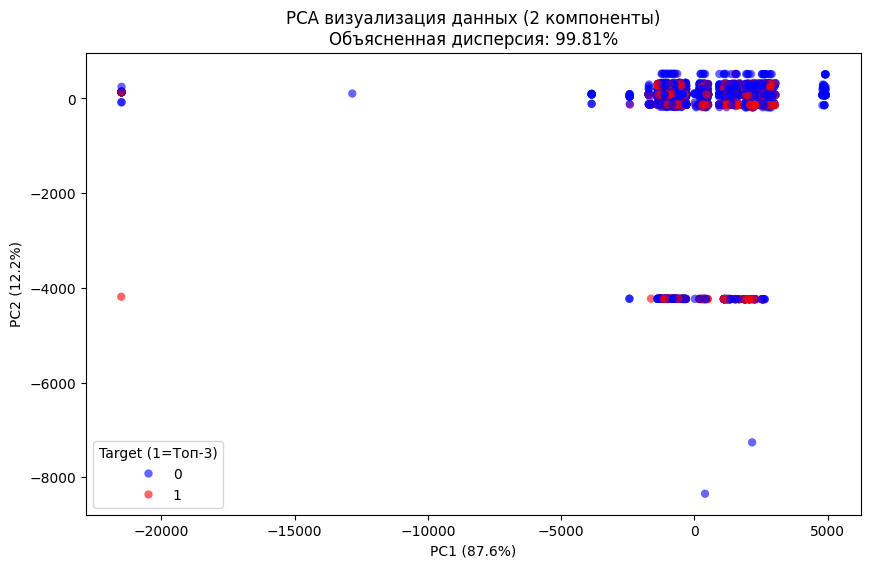

In [3]:
preprocessor = preprocess_pipeline(X_train)
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print(f"Размер после предобработки: {X_train_processed.shape}")

pca_2d = PCA(n_components=2, random_state=42)
X_train_pca_2d = pca_2d.fit_transform(X_train_processed)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_train_pca_2d[:, 0],
    y=X_train_pca_2d[:, 1],
    hue=y_train,
    palette={0: 'blue', 1: 'red'},
    alpha=0.6,
    edgecolor='none'
)
plt.title(f'PCA визуализация данных (2 компоненты)\nОбъясненная дисперсия: {pca_2d.explained_variance_ratio_.sum():.2%}')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
plt.legend(title='Target (1=Топ-3)')
plt.savefig('../report/images/pca_2d.png')
plt.show()


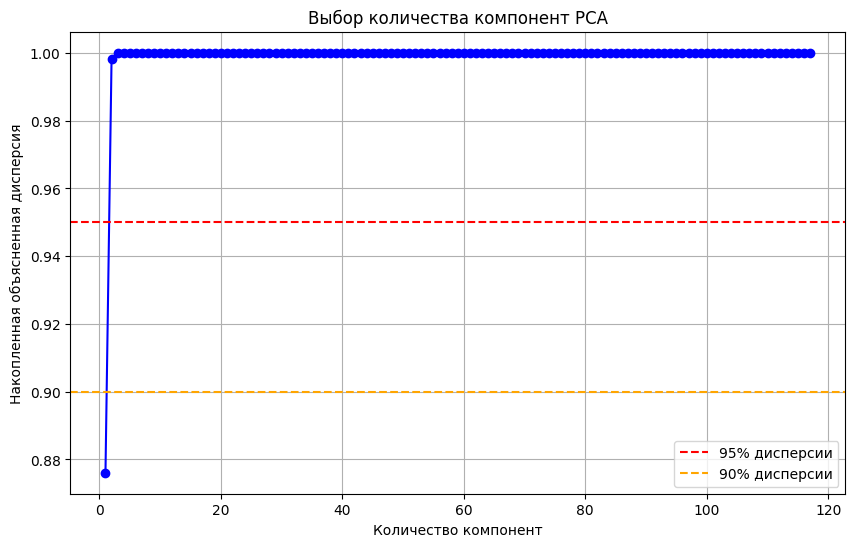

Компонент для 95% дисперсии: 2
Компонент для 90% дисперсии: 2


In [4]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train_processed)

cumsum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumsum) + 1), cumsum, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
plt.axhline(y=0.90, color='orange', linestyle='--', label='90% дисперсии')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная объясненная дисперсия')
plt.title('Выбор количества компонент PCA')
plt.legend()
plt.grid(True)
plt.savefig('../report/images/pca_cumulative_variance.png')
plt.show()
n_components_95 = np.argmax(cumsum >= 0.95) + 1
n_components_90 = np.argmax(cumsum >= 0.90) + 1
print(f"Компонент для 95% дисперсии: {n_components_95}")
print(f"Компонент для 90% дисперсии: {n_components_90}")

In [5]:
print("\n=== Эксперименты с PCA ===")

pca_results = []

for n_comp in [n_components_90, n_components_95, 50, 100]:
    pca = PCA(n_components=n_comp, random_state=42)
    X_train_pca = pca.fit_transform(X_train_processed)
    X_val_pca = pca.transform(X_val_processed)

    gb_pca = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        random_state=42
    )
    gb_pca.fit(X_train_pca, y_train)
    
    y_pred_proba = gb_pca.predict_proba(X_val_pca)[:, 1]
    y_pred = gb_pca.predict(X_val_pca)
    
    roc_auc = roc_auc_score(y_val, y_pred_proba)
    f1 = f1_score(y_val, y_pred)
    
    pca_results.append({
        'n_components': n_comp,
        'explained_variance': pca.explained_variance_ratio_.sum(),
        'roc_auc': roc_auc,
        'f1_score': f1
    })
    
    print(f"Компонент: {n_comp}, Дисперсия: {pca.explained_variance_ratio_.sum():.2%}, ROC-AUC: {roc_auc:.4f}, F1: {f1:.4f}")

pca_df = pd.DataFrame(pca_results)
print("\nРезультаты PCA экспериментов:")
print(pca_df)


=== Эксперименты с PCA ===
Компонент: 2, Дисперсия: 99.81%, ROC-AUC: 0.6054, F1: 0.0141
Компонент: 2, Дисперсия: 99.81%, ROC-AUC: 0.6054, F1: 0.0141
Компонент: 50, Дисперсия: 100.00%, ROC-AUC: 0.7215, F1: 0.0623
Компонент: 100, Дисперсия: 100.00%, ROC-AUC: 0.7194, F1: 0.0380

Результаты PCA экспериментов:
   n_components  explained_variance   roc_auc  f1_score
0             2             0.99808  0.605427  0.014070
1             2             0.99808  0.605427  0.014070
2            50             1.00000  0.721540  0.062257
3           100             1.00000  0.719413  0.038000


In [6]:
print("\n=== Сравнение: полные признаки vs PCA ===")
print(f"Исходная модель (без PCA): ROC-AUC = 0.784, F1 = 0.413")
best_pca = pca_df.loc[pca_df['roc_auc'].idxmax()]
print(f"Лучший PCA: {best_pca['n_components']} компонент, ROC-AUC = {best_pca['roc_auc']:.4f}, F1 = {best_pca['f1_score']:.4f}")


=== Сравнение: полные признаки vs PCA ===
Исходная модель (без PCA): ROC-AUC = 0.784, F1 = 0.413
Лучший PCA: 50.0 компонент, ROC-AUC = 0.7215, F1 = 0.0623


In [7]:
preprocessor = preprocess_pipeline(X_train)

model_params = {'solver': 'liblinear', 'random_state': 42, 'class_weight': 'balanced'}

baseline_model = train_model(X_train, y_train, preprocessor, model_params=model_params, use_smote=False)

logging.info("Оценка модели на валидационной выборке:")
val_metrics = evaluate_model(baseline_model, X_val, y_val, dataset_name="Validation")


2026-04-25 00:10:42,577 - INFO - Создание пайплайна предобработки...
2026-04-25 00:10:42,580 - INFO - Числовые признаки для StandardScaler: ['race_number', 'distance', 'prize_money', 'starting_position', 'jockey_weight', 'odds', 'horse_age', 'year', 'month', 'day_of_week', 'day_of_year', 'race_season', 'prize_per_distance', 'jockey_weight_per_age']
2026-04-25 00:10:42,582 - INFO - Категориальные признаки для OneHotEncoder: ['track', 'surface', 'country', 'trainername', 'racetype']
2026-04-25 00:10:42,582 - INFO - Пайплайн предобработки создан.
2026-04-25 00:10:42,584 - INFO - Начало обучения модели...
2026-04-25 00:10:42,961 - INFO - Обучение модели завершено.
2026-04-25 00:10:42,963 - INFO - Оценка модели на валидационной выборке:
2026-04-25 00:10:42,964 - INFO - Начало оценки модели на Validation наборе данных...
2026-04-25 00:10:43,011 - INFO - Метрики на Validation наборе данных:
2026-04-25 00:10:43,013 - INFO -   ROC AUC: 0.7668
2026-04-25 00:10:43,014 - INFO -   F1-Score: 0.5125


In [8]:
logging.info("Оценка модели на тестовой выборке:") 
test_metrics = evaluate_model(baseline_model, X_test, y_test, dataset_name="Test")

2026-04-25 00:10:43,033 - INFO - Оценка модели на тестовой выборке:
2026-04-25 00:10:43,034 - INFO - Начало оценки модели на Test наборе данных...
2026-04-25 00:10:43,081 - INFO - Метрики на Test наборе данных:
2026-04-25 00:10:43,083 - INFO -   ROC AUC: 0.7673
2026-04-25 00:10:43,084 - INFO -   F1-Score: 0.5189
2026-04-25 00:10:43,085 - INFO -   Precision: 0.3712
2026-04-25 00:10:43,086 - INFO -   Recall: 0.8622
2026-04-25 00:10:43,096 - INFO - 
              precision    recall  f1-score   support

           0       0.92      0.53      0.67      3058
           1       0.37      0.86      0.52       994

    accuracy                           0.61      4052
   macro avg       0.65      0.69      0.59      4052
weighted avg       0.79      0.61      0.63      4052



In [9]:
logging.info("Запуск экспериментов с несколькими моделями...")

results_df = run_experiments( X_train, y_train, X_val, y_val, preprocessor )

top_models = results_df.sort_values("roc_auc", ascending=False).head(10) 
print(top_models)

2026-04-25 00:10:43,103 - INFO - Запуск экспериментов с несколькими моделями...



=== Model: logreg ===


C:\Users\shche\PycharmProjects\Ml_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026-04-25 00:10:45,384 - INFO - Начало оценки модели на logreg наборе данных...
2026-04-25 00:10:45,427 - INFO - Метрики на logreg наборе данных:
2026-04-25 00:10:45,429 - INFO -   ROC AUC: 0.7728
2026-04-25 00:10:45,430 - INFO -   F1-Score: 0.5142
2026-04-25 00:10:45,430 - INFO -   Precision: 0.3681
2026-04-25 00:10:45,431 - INFO -   Recall: 0.8525
2026-04-25 00:10:45,443 - INFO - 



=== Model: rf ===


2026-04-25 00:10:51,781 - INFO - Начало оценки модели на rf наборе данных...
C:\Users\shche\PycharmProjects\Ml_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026-04-25 00:10:51,907 - INFO - Метрики на rf наборе данных:
2026-04-25 00:10:51,908 - INFO -   ROC AUC: 0.7471
2026-04-25 00:10:51,910 - INFO -   F1-Score: 0.0000
2026-04-25 00:10:51,911 - INFO -   Precision: 0.0000
2026-04-25 00:10:51,912 - INFO -   Recall: 0.0000
C:\Users\shche\PycharmProjects\Ml_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capit

...


=== Model: knn ===


2026-04-25 00:11:44,567 - INFO - Метрики на knn наборе данных:
2026-04-25 00:11:44,568 - INFO -   ROC AUC: 0.5652
2026-04-25 00:11:44,569 - INFO -   F1-Score: 0.2383
2026-04-25 00:11:44,570 - INFO -   Precision: 0.3333
2026-04-25 00:11:44,571 - INFO -   Recall: 0.1855
2026-04-25 00:11:44,586 - INFO - 
              precision    recall  f1-score   support

           0       0.77      0.88      0.82      3075
           1       0.33      0.19      0.24       976

    accuracy                           0.71      4051
   macro avg       0.55      0.53      0.53      4051
weighted avg       0.67      0.71      0.68      4051

2026-04-25 00:11:44,639 - INFO - Начало оценки модели на knn наборе данных...
2026-04-25 00:11:49,506 - INFO - Метрики на knn наборе данных:
2026-04-25 00:11:49,508 - INFO -   ROC AUC: 0.5599
2026-04-25 00:11:49,509 - INFO -   F1-Score: 0.1626
2026-04-25 00:11:49,510 - INFO -   Precision: 0.3937
2026-04-25 00:11:49,511 - INFO -   Recall: 0.1025
2026-04-25 00:11:49,525


=== Model: xgb ===


2026-04-25 00:11:54,584 - INFO - Начало оценки модели на xgb наборе данных...
2026-04-25 00:11:54,653 - INFO - Метрики на xgb наборе данных:
2026-04-25 00:11:54,654 - INFO -   ROC AUC: 0.7824
2026-04-25 00:11:54,655 - INFO -   F1-Score: 0.3980
2026-04-25 00:11:54,656 - INFO -   Precision: 0.6297
2026-04-25 00:11:54,657 - INFO -   Recall: 0.2910
2026-04-25 00:11:54,672 - INFO - 
              precision    recall  f1-score   support

           0       0.81      0.95      0.87      3075
           1       0.63      0.29      0.40       976

    accuracy                           0.79      4051
   macro avg       0.72      0.62      0.63      4051
weighted avg       0.76      0.79      0.76      4051

2026-04-25 00:11:54,908 - INFO - Начало оценки модели на xgb наборе данных...
2026-04-25 00:11:54,975 - INFO - Метрики на xgb наборе данных:
2026-04-25 00:11:54,976 - INFO -   ROC AUC: 0.7757
2026-04-25 00:11:54,977 - INFO -   F1-Score: 0.3911
2026-04-25 00:11:54,978 - INFO -   Precision: 0.

     model                                           pipeline  classifier__C  \
6       gb  (ColumnTransformer(remainder='passthrough',\n ...            NaN   
11     xgb  (ColumnTransformer(remainder='passthrough',\n ...            NaN   
7       gb  (ColumnTransformer(remainder='passthrough',\n ...            NaN   
13     xgb  (ColumnTransformer(remainder='passthrough',\n ...            NaN   
12     xgb  (ColumnTransformer(remainder='passthrough',\n ...            NaN   
0   logreg  (ColumnTransformer(remainder='passthrough',\n ...            0.1   
2   logreg  (ColumnTransformer(remainder='passthrough',\n ...           10.0   
1   logreg  (ColumnTransformer(remainder='passthrough',\n ...            1.0   
14     xgb  (ColumnTransformer(remainder='passthrough',\n ...            NaN   
5       rf  (ColumnTransformer(remainder='passthrough',\n ...            NaN   

     roc_auc  f1_score  precision    recall  classifier__max_depth  \
6   0.783774  0.413370   0.618367  0.310451      

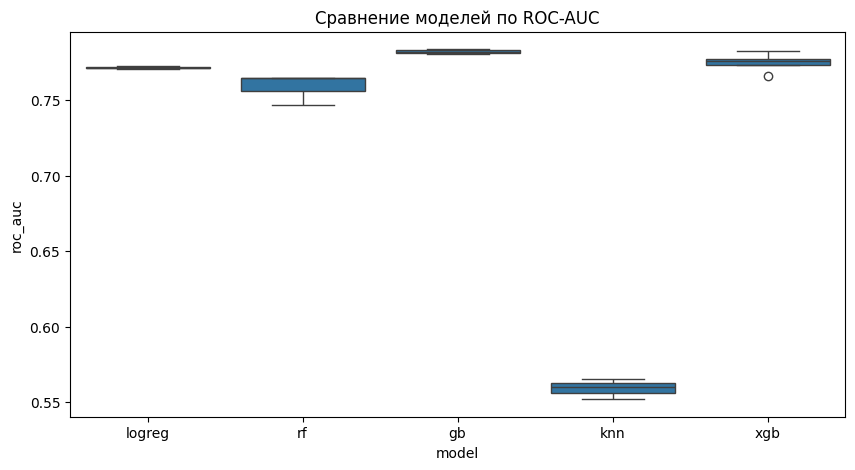

Лучшая модель:
model                                                                       gb
pipeline                     (ColumnTransformer(remainder='passthrough',\n ...
classifier__C                                                              NaN
roc_auc                                                               0.783774
f1_score                                                               0.41337
precision                                                             0.618367
recall                                                                0.310451
classifier__max_depth                                                      NaN
classifier__n_estimators                                                 100.0
classifier__learning_rate                                                 0.05
classifier__n_neighbors                                                    NaN
Name: 6, dtype: object


In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=results_df, x="model", y="roc_auc")
plt.title("Сравнение моделей по ROC-AUC")
plt.savefig('../report/images/model_comparison.png')
plt.show()

best_row = results_df.sort_values("roc_auc", ascending=False).iloc[0]
print("Лучшая модель:")
print(best_row)


<Figure size 800x600 with 0 Axes>

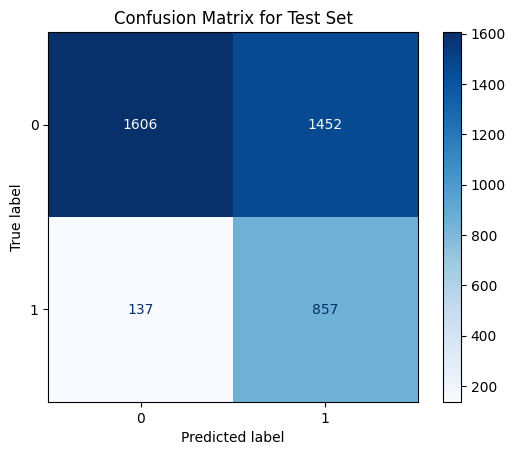

2026-04-25 00:11:56,297 - INFO - Сохранение модели в ../models/best_model.joblib...
2026-04-25 00:11:56,305 - INFO - Модель успешно сохранена.
2026-04-25 00:11:56,306 - INFO - Базовый пайплайн завершен.


Лучшая модель:
model                                                                       gb
pipeline                     (ColumnTransformer(remainder='passthrough',\n ...
classifier__C                                                              NaN
roc_auc                                                               0.783774
f1_score                                                               0.41337
precision                                                             0.618367
recall                                                                0.310451
classifier__max_depth                                                      NaN
classifier__n_estimators                                                 100.0
classifier__learning_rate                                                 0.05
classifier__n_neighbors                                                    NaN
Name: 6, dtype: object


In [11]:
plt.figure(figsize=(8, 6))
y_pred_test = baseline_model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap='Blues')
plt.title('Confusion Matrix for Test Set')
plt.savefig('../report/images/confusion_matrix_baseline.png') 
plt.show()

best_row = results_df.sort_values("roc_auc", ascending=False).iloc[0]
best_model = best_row["pipeline"]
print("Лучшая модель:")
print(best_row)

best_model_path = '../models/best_model.joblib'
save_model(best_model, best_model_path)

logging.info("Базовый пайплайн завершен.")

In [12]:
## Обоснование выбора метрик качества

В задаче бинарной классификации (попадание лошади в топ-3 или нет) классы несбалансированы: примерно 75% наблюдений — класс 0, 25% — класс 1.

Основная метрика: ROC-AUC
- Не зависит от порога классификации
- Устойчива к дисбалансу классов
- Позволяет оценить способность разделять классы при любом пороге

Дополнительные метрики:
- Precision - доля верно предсказанных топ-3 среди всех предсказанных как топ-3. Важна, если ложные срабатывания дороги (например, ошибочная рекомендация ставки)
- Recall - доля найденных топ-3 среди всех реальных топ-3. Важен, если нельзя пропускать потенциальных победителей
- F1-score - гармоническое среднее precision и recall, полезен для сравнения моделей

Приоритет: ROC-AUC → F1 → Precision/Recall. При равном ROC-AUC выбираем модель с лучшим F1.

SyntaxError: invalid character '—' (U+2014) (2508738680.py, line 3)

In [ ]:
## Обоснование выбора финальной модели

Выбрана модель: Gradient Boosting (learning_rate=0.05, n_estimators=100)

Результаты на валидации:
| Модель | ROC-AUC | F1 | Precision | Recall |
|--------|---------|-----|-----------|--------|
| Gradient Boosting | 0.784 | 0.413 | 0.618 | 0.310 |
| Logistic Regression | 0.768 | 0.513 | 0.370 | 0.835 |
| Random Forest | 0.765 | 0.134 | 0.720 | 0.074 |
| KNN | 0.565 | 0.238 | 0.333 | 0.185 |

Почему не логистическая регрессия?
- Высокий recall (0.835), но очень низкая precision (0.370)
- Это приводит к множеству ложных срабатываний
- Приоритет в задаче - точность предсказания топ-3

Почему не Random Forest?
- Низкий recall (0.074) - модель практически игнорирует класс 1
- F1-score = 0.134 - очень плохо 

Почему Gradient Boosting?
- Максимальный ROC-AUC (0.784)
- Лучший баланс precision (0.618) и recall (0.310)
- Более устойчив к переобучению при данных параметрах

Итог: Gradient Boosting обеспечивает наилучшее разделение классов и сбалансированные показатели точности и полноты.